# EEG Meditation Study — ERP & Power Spectral Analysis

Basic analysis of cortical responses to mindfulness interruption prompts using event-related potentials (ERP) and power spectral density (PSD) from a publicly available meditation EEG dataset.

Arnaud Delorme and Tracy Brandmeyer (2024). EEG meditation study. OpenNeuro. [Dataset] doi: doi:10.18112/openneuro.ds001787.v1.1.1

Munna R. Shainy [[Find me on LinkedIn]](https://www.linkedin.com/in/munnars/)

Year: 2026

In [44]:
import mne
print("MNE version:", mne.__version__)

MNE version: 1.11.0


In [45]:
import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#testing with one sample first

raw_path = 'data/sub-001/ses-01/eeg/sub-001_ses-01_task-meditation_eeg.bdf'

raw = mne.io.read_raw_bdf(raw_path, preload=True)


print(raw.info)


print(raw.ch_names)


# EXG and  other channels-rename
raw.set_channel_types({
    'EXG1': 'eog',
    'EXG2': 'eog',
    'EXG3': 'eog',
    'EXG4': 'eog',
    'EXG5': 'eog',
    'EXG6': 'eog',
    'EXG7': 'eog',
    'EXG8': 'eog',
    'GSR1': 'misc',
    'GSR2': 'misc',
    'Erg1': 'misc',
    'Erg2': 'misc',
    'Resp': 'misc',
    'Plet': 'misc',
    'Temp': 'misc'
})

print(raw.get_channel_types())

# BioSemi A1-B32 to standard 10-20 mapping
biosemi_to_standard = {
    'A1': 'Fp1', 'A2': 'AF7', 'A3': 'AF3', 'A4': 'F1',
    'A5': 'F3', 'A6': 'F5', 'A7': 'F7', 'A8': 'FT7',
    'A9': 'FC5', 'A10': 'FC3', 'A11': 'FC1', 'A12': 'C1',
    'A13': 'C3', 'A14': 'C5', 'A15': 'T7', 'A16': 'TP7',
    'A17': 'CP5', 'A18': 'CP3', 'A19': 'CP1', 'A20': 'P1',
    'A21': 'P3', 'A22': 'P5', 'A23': 'P7', 'A24': 'P9',
    'A25': 'PO7', 'A26': 'PO3', 'A27': 'O1', 'A28': 'Iz',
    'A29': 'Oz', 'A30': 'POz', 'A31': 'Pz', 'A32': 'CPz',
    'B1': 'Fpz', 'B2': 'Fp2', 'B3': 'AF8', 'B4': 'AF4',
    'B5': 'AFz', 'B6': 'Fz', 'B7': 'F2', 'B8': 'F4',
    'B9': 'F6', 'B10': 'F8', 'B11': 'FT8', 'B12': 'FC6',
    'B13': 'FC4', 'B14': 'FC2', 'B15': 'FCz', 'B16': 'Cz',
    'B17': 'C2', 'B18': 'C4', 'B19': 'C6', 'B20': 'T8',
    'B21': 'TP8', 'B22': 'CP6', 'B23': 'CP4', 'B24': 'CP2',
    'B25': 'P2', 'B26': 'P4', 'B27': 'P6', 'B28': 'P8',
    'B29': 'P10', 'B30': 'PO8', 'B31': 'PO4', 'B32': 'O2'
}

raw.rename_channels(biosemi_to_standard)

# Applying montage
montage = mne.channels.make_standard_montage('biosemi64')
raw.set_montage(montage, on_missing='ignore')
raw.ch_names[:5]

Extracting BDF parameters from data/sub-001/ses-01/eeg/sub-001_ses-01_task-meditation_eeg.bdf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 696575  =      0.000 ...  2720.996 secs...
<Info | 8 non-empty values
 bads: []
 ch_names: A1, A2, A3, A4, A5, A6, A7, A8, A9, A10, A11, A12, A13, A14, ...
 chs: 79 EEG, 1 Stimulus
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 52.0 Hz
 meas_date: 2014-04-04 19:40:17 UTC
 nchan: 80
 projs: []
 sfreq: 256.0 Hz
 subject_info: <subject_info | his_id: >
>
['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15', 'A16', 'A17', 'A18', 'A19', 'A20', 'A21', 'A22', 'A23', 'A24', 'A25', 'A26', 'A27', 'A28', 'A29', 'A30', 'A31', 'A32', 'B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B9', 'B10', 'B11', 'B12', 'B13', 'B14', 'B15', 'B16', 'B17', 'B18', 'B19', 'B20', 'B21', 'B22', 'B23', 'B24', 'B25', 'B26', 'B27', 'B28', 'B29', 'B30', 'B31', 'B32', 'EXG1', 'EXG2', 'EXG3', 'EXG4',

/var/folders/49/yw4qfd597nv_r612jnk_ndgw0000gn/T/ipykernel_72957/82159554.py:20: RuntimeWarning: The unit for channel(s) Erg1, Erg2, GSR1, GSR2, Plet, Resp, Temp has changed from V to NA.
  raw.set_channel_types({


['Fp1', 'AF7', 'AF3', 'F1', 'F3']

In [46]:
# Loading the events file
events_path = 'data/sub-001/ses-01/eeg/sub-001_ses-01_task-meditation_events.tsv'
events_df = pd.read_csv(events_path, sep='\t')

print("Events file shape:", events_df.shape)
print("\nColumn names:", events_df.columns.tolist())
print(events_df.head(5))
print(events_df['trial_type'].value_counts())

Events file shape: (87, 6)

Column names: ['onset', 'duration', 'trial_type', 'response_time', 'sample', 'value']
        onset  duration trial_type  response_time   sample  value
0   71.386719       NaN   stimulus            NaN  18275.0    128
1   75.730469       NaN   response            NaN  19387.0      2
2   79.773438       NaN   response            NaN  20422.0      2
3  125.609375       NaN   stimulus            NaN  32156.0    128
4  179.800781       NaN   stimulus            NaN  46029.0    128
trial_type
response    59
stimulus    28
Name: count, dtype: int64


In [47]:
raw_filtered = raw.copy()

# Applying bandpass filter (0.1 - 40 Hz)
raw_filtered.filter(l_freq=0.1, h_freq=40.0, 
                    method='fir', 
                    fir_window='hamming')

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 8449 samples (33.004 s)



<RawBDF | sub-001_ses-01_task-meditation_eeg.bdf, 80 x 696576 (2721.0 s), ~425.2 MiB, data loaded>

In [48]:
#Extracting events from the stimulus channel
events = mne.find_events(raw_filtered, 
                         stim_channel='Status', #BioSemi ActiveTwo systems generally have a channel for stimulus info
                         min_duration=1/256) #removing trigger pulses shorter than one sample, filtering out noise

Finding events on: Status
Trigger channel Status has a non-zero initial value of 65536 (consider using initial_event=True to detect this event)
Removing orphaned offset at the beginning of the file.
87 events found on stim channel Status
Event IDs: [  2   4 128]


In [49]:
# Define event id
event_id = {'stimulus': 128}

# Create epochs time-locked to stimulus onset
epochs = mne.Epochs(raw_filtered,
                    events,
                    event_id=event_id,
                    tmin=-0.2,    # 200ms before stimulus
                    tmax=0.8,     # 800ms after stimulus
                    baseline=(-0.2, 0),  # baseline correction
                    preload=True,
                    reject=None)  

Not setting metadata
28 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 28 events and 257 original time points ...
0 bad epochs dropped


In [50]:
# Check epoch amplitude ranges for artifact detection
peak_to_peak = np.ptp(epochs.get_data(), axis=2)  # peak-to-peak per channel per epoch

print("Peak-to-peak amplitude stats (microvolts):")
f"Mean: {peak_to_peak.mean()*1e6:.2f}"
f"Max: {peak_to_peak.max()*1e6:.2f}"
f"Min: {peak_to_peak.min()*1e6:.2f}"

# Reject epochs with extreme amplitudes (>150 microvolts = likely artifact)
reject_criteria = dict(eeg=150e-6)  # 150 microvolts in volts

epochs_clean = mne.Epochs(raw_filtered,
                           events,
                           event_id=event_id,
                           tmin=-0.2,
                           tmax=0.8,
                           baseline=(-0.2, 0),
                           preload=True,
                           reject=reject_criteria)

print(f"\nEpochs before rejection: 28")
print(f"Epochs after rejection: {len(epochs_clean)}")
print(f"Epochs rejected: {28 - len(epochs_clean)}")

Peak-to-peak amplitude stats (microvolts):
Not setting metadata
28 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 28 events and 257 original time points ...
    Rejecting  epoch based on EEG : ['Fp1', 'AF7', 'F7', 'FT7', 'FC5', 'T7', 'TP7', 'P7', 'P9', 'PO7', 'PO3', 'Fpz', 'Fp2', 'AF8', 'F8', 'FT8', 'FC6', 'T8', 'TP8', 'CP6', 'P8', 'P10']
    Rejecting  epoch based on EEG : ['AF7', 'F7', 'FT7', 'T7', 'Oz', 'Fpz', 'Fp2', 'AF8', 'F8']
    Rejecting  epoch based on EEG : ['Fp1', 'AF7', 'F7', 'FT7', 'FC5', 'T7', 'P7', 'P9', 'PO7', 'O1', 'Iz', 'Oz', 'Fpz', 'Fp2', 'AF8', 'AFz', 'F4', 'F8', 'FT8', 'P10', 'PO8', 'PO4', 'O2']
    Rejecting  epoch based on EEG : ['Fp1', 'AF7', 'F7', 'P9', 'Oz', 'Fpz', 'Fp2', 'AF8', 'F8']
    Rejecting  epoch based on EEG : ['T7', 'F8', 'P10']
    Rejecting  epoch based on EEG : ['F6']
    Rejecting  epoch based on EEG : ['FT7', 'FC5', 'F8']
    Rejecting  epoch based on EEG : ['F7', 

/var/folders/49/yw4qfd597nv_r612jnk_ndgw0000gn/T/ipykernel_72957/622877659.py:13: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


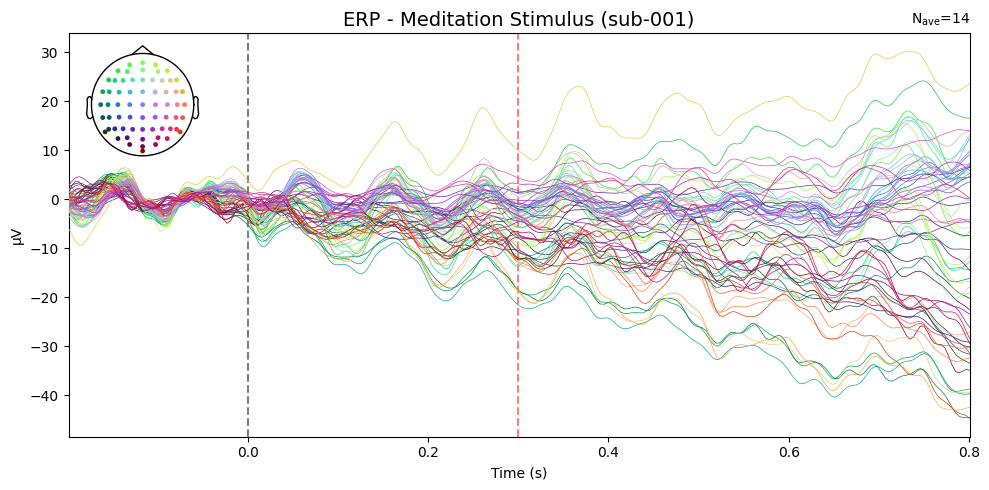

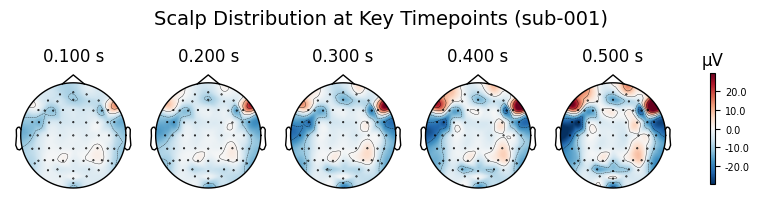

In [51]:
epochs_clean.set_montage(montage, on_missing='ignore')
evoked = epochs_clean.average()

# Butterfly plot with spatial colors
fig1, ax1 = plt.subplots(figsize=(10, 5))

evoked.plot(spatial_colors=True,
            axes=ax1,
            show=False)
ax1.set_title('ERP - Meditation Stimulus (sub-001)', fontsize=14)
ax1.axvline(x=0, color='black', linestyle='--', alpha=0.5, label='Stimulus onset')
ax1.axvline(x=0.3, color='red', linestyle='--', alpha=0.5, label='P300 window')
plt.tight_layout()
plt.savefig('figures/01_erp_butterfly_sub001.png', dpi=150, bbox_inches='tight')
plt.show()

fig2 = evoked.plot_topomap(times=[0.1, 0.2, 0.3, 0.4, 0.5],
                            ch_type='eeg',
                            show=False)
fig2.suptitle('Scalp Distribution at Key Timepoints (sub-001)', fontsize=14)

fig2.savefig('figures/02_topomap_sub001.png', dpi=150, bbox_inches='tight')  # ← save from fig object
plt.show()


In [52]:
# Processing all 5 subjects and collect evoked responses
all_evoked = []
subjects = ['sub-001', 'sub-002', 'sub-003', 'sub-004', 'sub-005']

for sub in subjects:
    print(f"\nProcessing {sub}...")
    
    # Loading raw data
    bdf_path = f'data/{sub}/ses-01/eeg/{sub}_ses-01_task-meditation_eeg.bdf'
    raw = mne.io.read_raw_bdf(bdf_path, preload=True, verbose=False)
    
    # Fix channel types
    raw.set_channel_types({
        'EXG1': 'eog', 'EXG2': 'eog', 'EXG3': 'eog', 'EXG4': 'eog',
        'EXG5': 'eog', 'EXG6': 'eog', 'EXG7': 'eog', 'EXG8': 'eog',
        'GSR1': 'misc', 'GSR2': 'misc', 'Erg1': 'misc', 'Erg2': 'misc',
        'Resp': 'misc', 'Plet': 'misc', 'Temp': 'misc'
    })
    
    # Renaming channels
    raw.rename_channels(biosemi_to_standard)
    
    # Applying montage
    montage = mne.channels.make_standard_montage('biosemi64')
    raw.set_montage(montage, on_missing='ignore')
    
    # Filtering
    raw.filter(l_freq=0.1, h_freq=40.0, method='fir', 
               fir_window='hamming', verbose=False)
    
    # Finding events
    events = mne.find_events(raw, stim_channel='Status', 
                             min_duration=1/256, verbose=False)
    
    # Epoching
    epochs = mne.Epochs(raw, events,
                        event_id={'stimulus': 128},
                        tmin=-0.2, tmax=0.8,
                        baseline=(-0.2, 0),
                        preload=True,
                        reject=dict(eeg=150e-6),
                        verbose=False)
    
    n_epochs = len(epochs)
    print(f"  Clean epochs: {n_epochs}")
    if n_epochs >= 5:
        evoked = epochs.average()
        all_evoked.append(evoked)
        print(f"  ✓ Added to grand average")
    else:
        print(f"  ✗ Too few epochs, skipping")

print(f"\nSubjects included in grand average: {len(all_evoked)}")


Processing sub-001...


/var/folders/49/yw4qfd597nv_r612jnk_ndgw0000gn/T/ipykernel_72957/3371999374.py:13: RuntimeWarning: The unit for channel(s) Erg1, Erg2, GSR1, GSR2, Plet, Resp, Temp has changed from V to NA.
  raw.set_channel_types({


  Clean epochs: 14
  ✓ Added to grand average

Processing sub-002...


/var/folders/49/yw4qfd597nv_r612jnk_ndgw0000gn/T/ipykernel_72957/3371999374.py:13: RuntimeWarning: The unit for channel(s) Erg1, Erg2, GSR1, GSR2, Plet, Resp, Temp has changed from V to NA.
  raw.set_channel_types({


  Clean epochs: 10
  ✓ Added to grand average

Processing sub-003...


...

  Clean epochs: 0
  ✗ Too few epochs, skipping

Processing sub-004...


/var/folders/49/yw4qfd597nv_r612jnk_ndgw0000gn/T/ipykernel_72957/3371999374.py:13: RuntimeWarning: The unit for channel(s) Erg1, Erg2, GSR1, GSR2, Plet, Resp, Temp has changed from V to NA.
  raw.set_channel_types({


  Clean epochs: 7
  ✓ Added to grand average

Processing sub-005...


/var/folders/49/yw4qfd597nv_r612jnk_ndgw0000gn/T/ipykernel_72957/3371999374.py:13: RuntimeWarning: The unit for channel(s) Erg1, Erg2, GSR1, GSR2, Plet, Resp, Temp has changed from V to NA.
  raw.set_channel_types({


  Clean epochs: 17
  ✓ Added to grand average

Subjects included in grand average: 4


Identifying common channels ...


/var/folders/49/yw4qfd597nv_r612jnk_ndgw0000gn/T/ipykernel_72957/1537359232.py:15: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


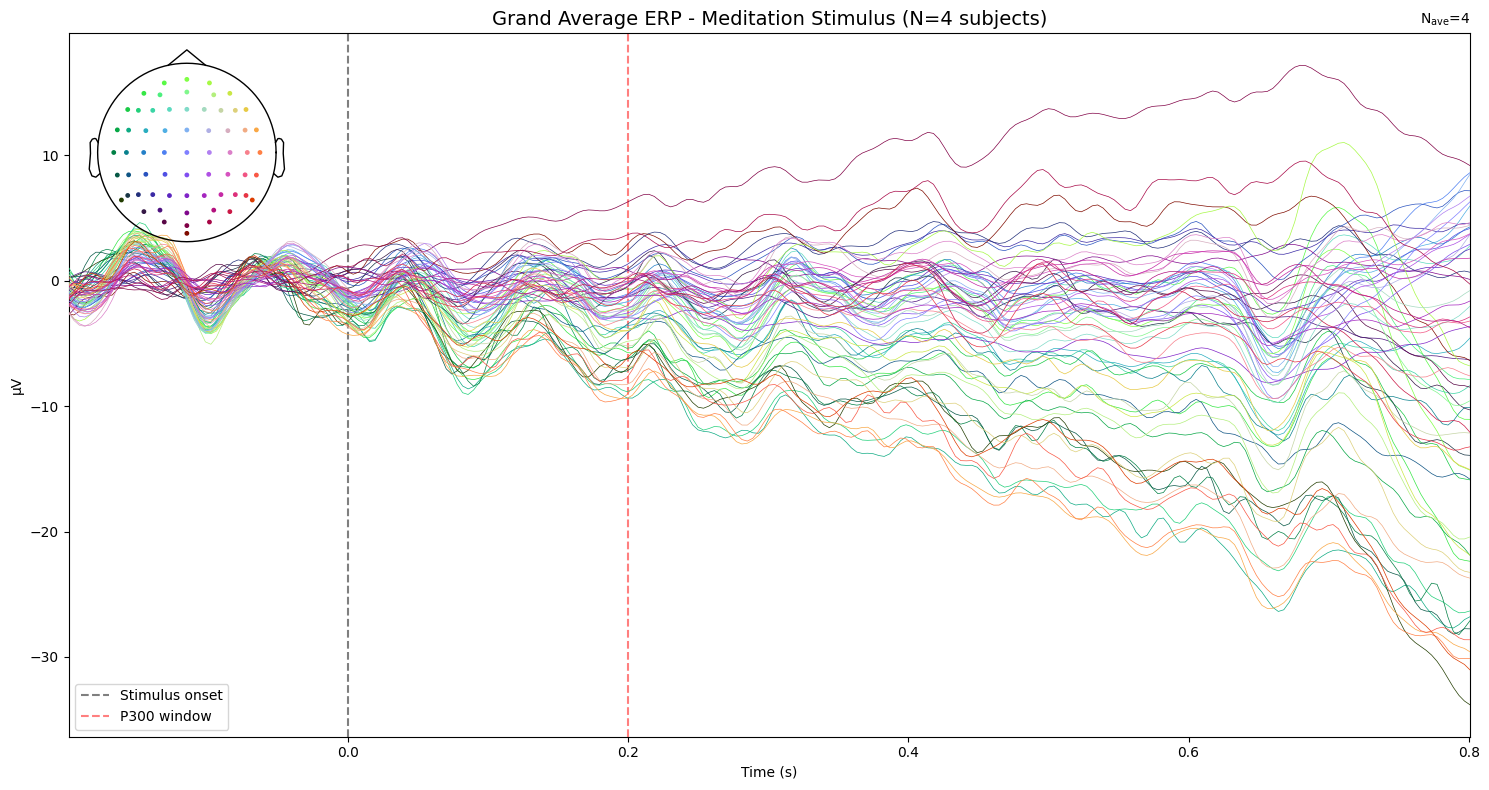

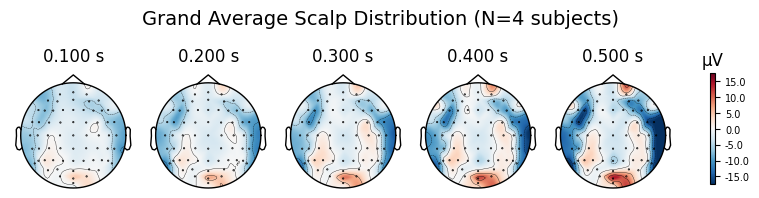

Grand average plots saved!


In [53]:
# Compute grand average across all subjects
grand_avg = mne.grand_average(all_evoked)

# Plot 1: Grand average butterfly plot
fig, ax = plt.subplots(figsize=(15, 8))
grand_avg.plot(spatial_colors=True,
               axes=ax,
               show=False)

ax.set_title(f'Grand Average ERP - Meditation Stimulus (N={len(all_evoked)} subjects)', 
             fontsize=14)
ax.axvline(x=0, color='black', linestyle='--', alpha=0.5, label='Stimulus onset')
ax.axvline(x=0.2, color='red', linestyle='--', alpha=0.5, label='P300 window')
ax.legend(fontsize=10, loc='lower left')
plt.tight_layout()
plt.savefig('figures/03_grand_avg_erp.png', dpi=150, bbox_inches='tight')
plt.show()

# Grand average topomaps
fig2 = grand_avg.plot_topomap(times=[0.1, 0.2, 0.3, 0.4, 0.5],
                               ch_type='eeg',
                               show=False)
fig2.suptitle(f'Grand Average Scalp Distribution (N={len(all_evoked)} subjects)', 
              fontsize=14)
plt.savefig('figures/04_grand_avg_topomap.png', dpi=150, bbox_inches='tight')
plt.show()



print("Grand average plots saved!")

Effective window size : 1.004 (s)
Effective window size : 1.004 (s)
Effective window size : 1.004 (s)
Effective window size : 1.004 (s)


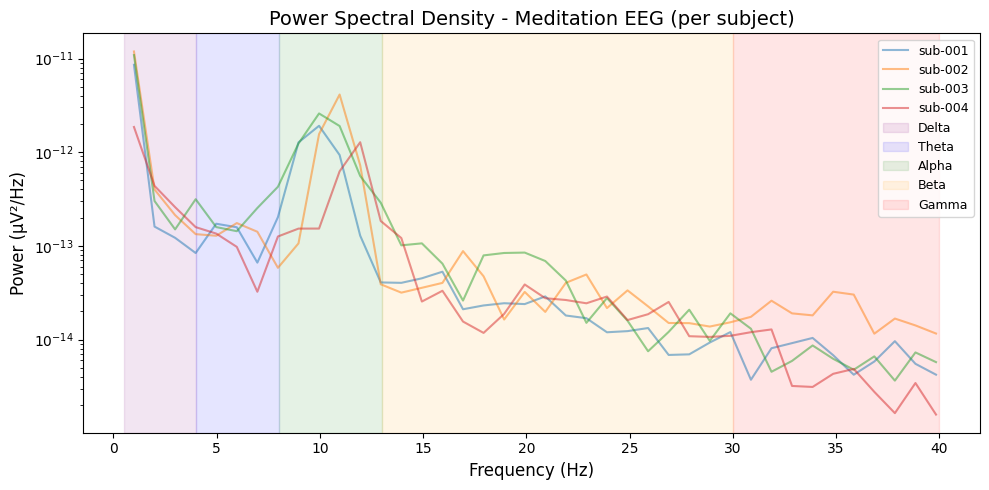

In [54]:
# Compute and plot PSD for grand average across subjects
fig, ax = plt.subplots(figsize=(10, 5))

for i, (sub, evoked) in enumerate(zip(subjects, all_evoked)):
    # Get PSD from epochs
    spectrum = evoked.compute_psd(method='welch',
                                   fmin=0.5,
                                   fmax=40.0)
    psds, freqs = spectrum.get_data(return_freqs=True)
    
    # Average across channels
    mean_psd = psds.mean(axis=0)
    
    # Plot
    ax.semilogy(freqs, mean_psd, alpha=0.5, label=sub)

ax.set_xlabel('Frequency (Hz)', fontsize=12)
ax.set_ylabel('Power (µV²/Hz)', fontsize=12)
ax.set_title('Power Spectral Density - Meditation EEG (per subject)', fontsize=14)

# Add frequency band annotations
ax.axvspan(0.5, 4, alpha=0.1, color='purple', label='Delta')
ax.axvspan(4, 8, alpha=0.1, color='blue', label='Theta')
ax.axvspan(8, 13, alpha=0.1, color='green', label='Alpha')
ax.axvspan(13, 30, alpha=0.1, color='orange', label='Beta')
ax.axvspan(30, 40, alpha=0.1, color='red', label='Gamma')

ax.legend(fontsize=9, loc='upper right')
plt.tight_layout()
plt.savefig('figures/05_psd_per_subject.png', dpi=150, bbox_inches='tight')
plt.show()

Effective window size : 1.004 (s)


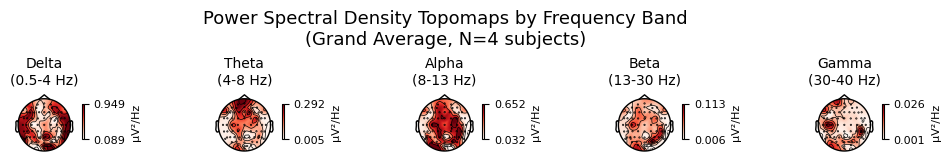

PSD topomap saved!


In [55]:
# Computing PSD on the grand average evoked object
grand_avg_spectrum = grand_avg.compute_psd(method='welch',
                                            fmin=0.5,
                                            fmax=40.0)

# Plot topomap for each frequency band
fig = grand_avg_spectrum.plot_topomap(
    bands={
        'Delta\n(0.5-4 Hz)': (0.5, 4),
        'Theta\n(4-8 Hz)': (4, 8),
        'Alpha\n(8-13 Hz)': (8, 13),
        'Beta\n(13-30 Hz)': (13, 30),
        'Gamma\n(30-40 Hz)': (30, 40)
    },
    ch_type='eeg',
    normalize=True,  #normalizing within each band for cleaner comparison
    show=False
)

fig.suptitle('Power Spectral Density Topomaps by Frequency Band\n(Grand Average, N=4 subjects)', 
             fontsize=13)
plt.savefig('figures/06_psd_topomap_bands.png', dpi=150, bbox_inches='tight')
plt.show()

print("PSD topomap saved!")